In [183]:
%pwd
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [184]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
from experiments.scripts.run_experiments import run_experiment
from experiments.scripts.experiment_utils import generate_experiments

In [185]:
base_config = {
    # Experiment
    "experiment": "ae_sphere_w50_b64",
    "random_seed": 42,
    "logging": True,

    # Dataset
    "dataset_name": "sphere_high_dim",
    "batch_size": 64,
    "rotation": "random",
    "translation": None,
    "deformation_amp": 10,
    "geodesic_distortion_amp": 10,
    "n_times": 8000, 
    "radius": 2.0,
    "embedding_dim": 10,
    "noise_var": 0.0005,
    "enclosing_sphere": False,

    # Model
    'model_type': 'EuclideanAE',
    'data_dim': 10,
    'latent_dim': 3,
    'sftbeta': 4.5,
    'device': "cpu",
    'encoder_widths': [50, 50, 50],
    'decoder_widths': [50, 50, 50],

    # Optimizer
    "learning_rate": 0.001,

    # Trainer
    'verbose': False,
    'num_epochs': 100,
    'log_interval': 100,
    'recon_loss': "MSE",
    'topo_loss': True,
    'dim_topo_loss': 2,
    'alpha': 1.0,  # Weight for reconstruction loss
    'beta': 0.0,  # Weight for KL loss
    'gamma': 0.0,  # Weight for topological loss

    # Curvature computation
    "plot_curvatures": True,
    "compute_true_curv": False,
    "compute_learned_curv": False,
    "compute_rec_curv": False,
    "n_plot_points": 2500,
    "n_points_emp_curv": 8000,  # number of points to compute the empirical curvature
    "n_points_pullback_curv": 8000,  # number of points to compute the pullback (true/learned). Should be 1000-2000.
    "k": 300,
    "smoothing": False,

    # Persistent homology
    "persistent_homology": False,
    "n_points_pers_hom": 1000,
    "scale": False,
    "homology_dimensions": [0, 1, 2]
}

param_grid = {
    "alpha": [1] * 3 + [1, 1, 1, 0] * 3,
    "gamma": [0] * 3 + [1, 100, 1000, 1] * 3,
    "dim_topo_loss": [0,1,2] + [0] * 4 + [1] * 4 + [2] * 4,
}

all_configs = generate_experiments(base_config, param_grid)



Running exp00_ae_sphere_w20_b64. 
Description: alpha=1, gamma=0, dim_topo_loss=0
--------------------------------------------------------------------------------------


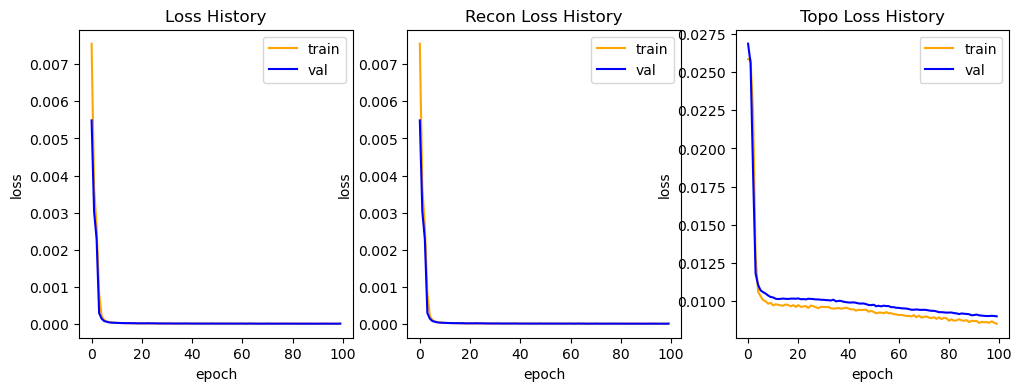

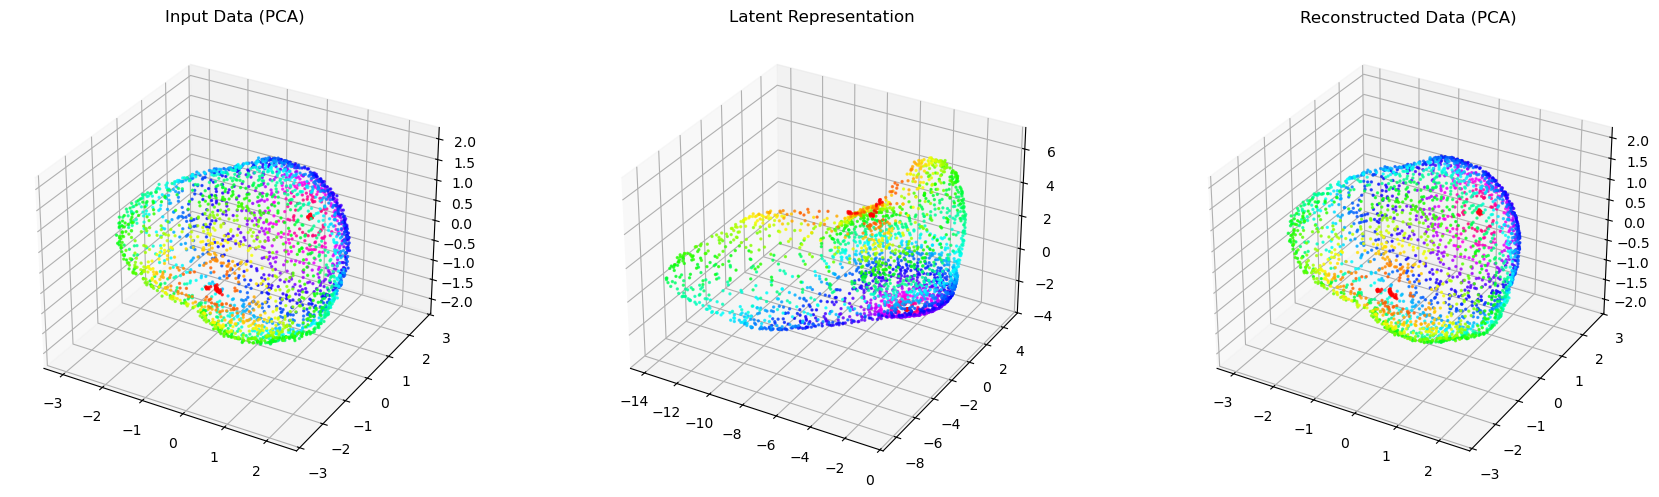

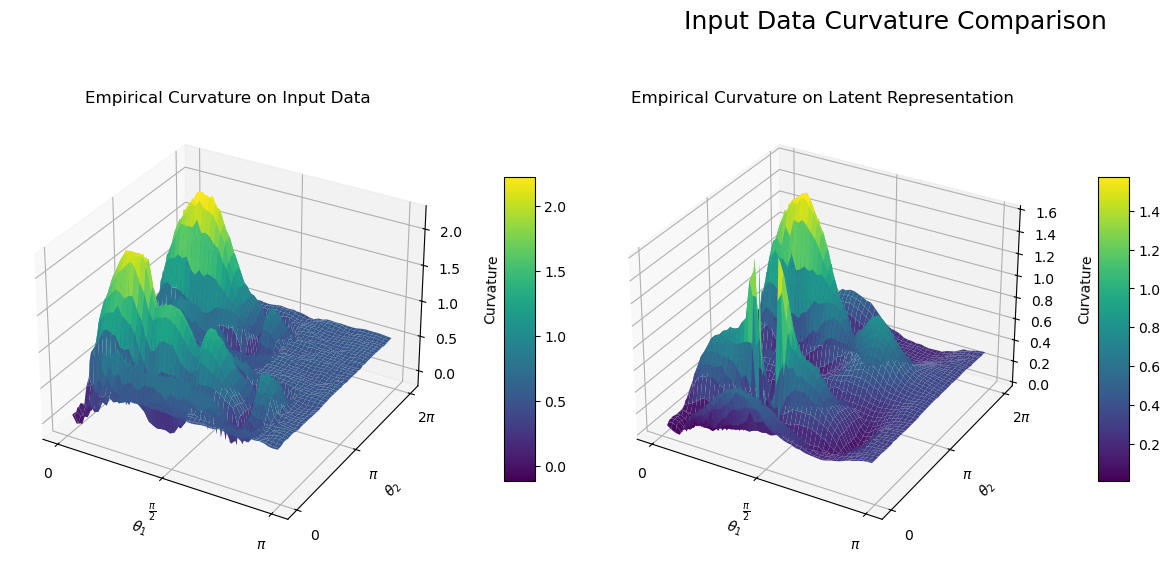

<Figure size 1800x1000 with 0 Axes>

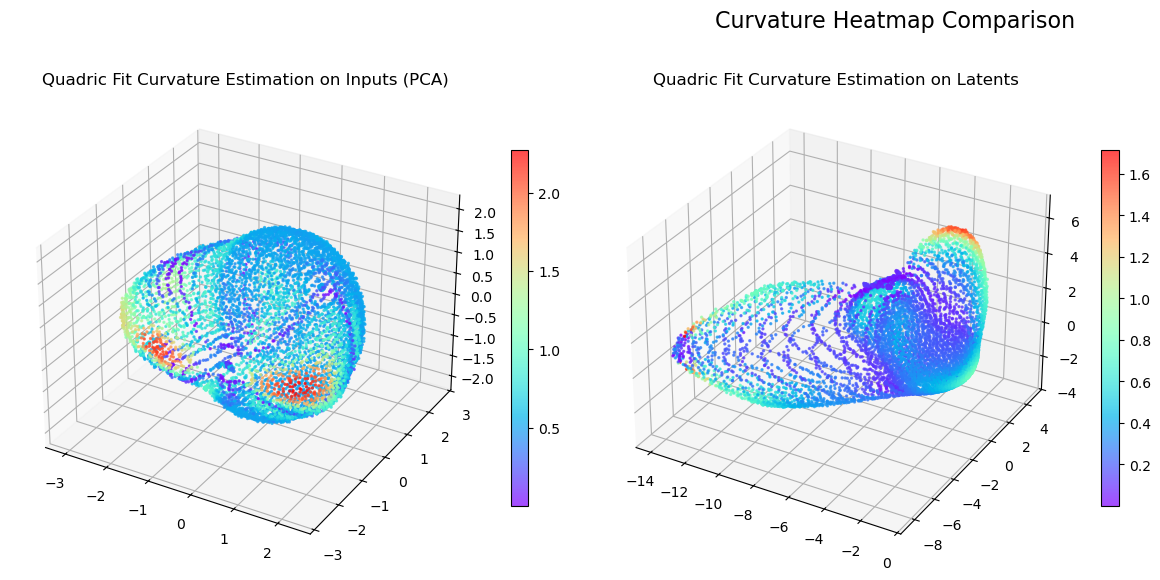

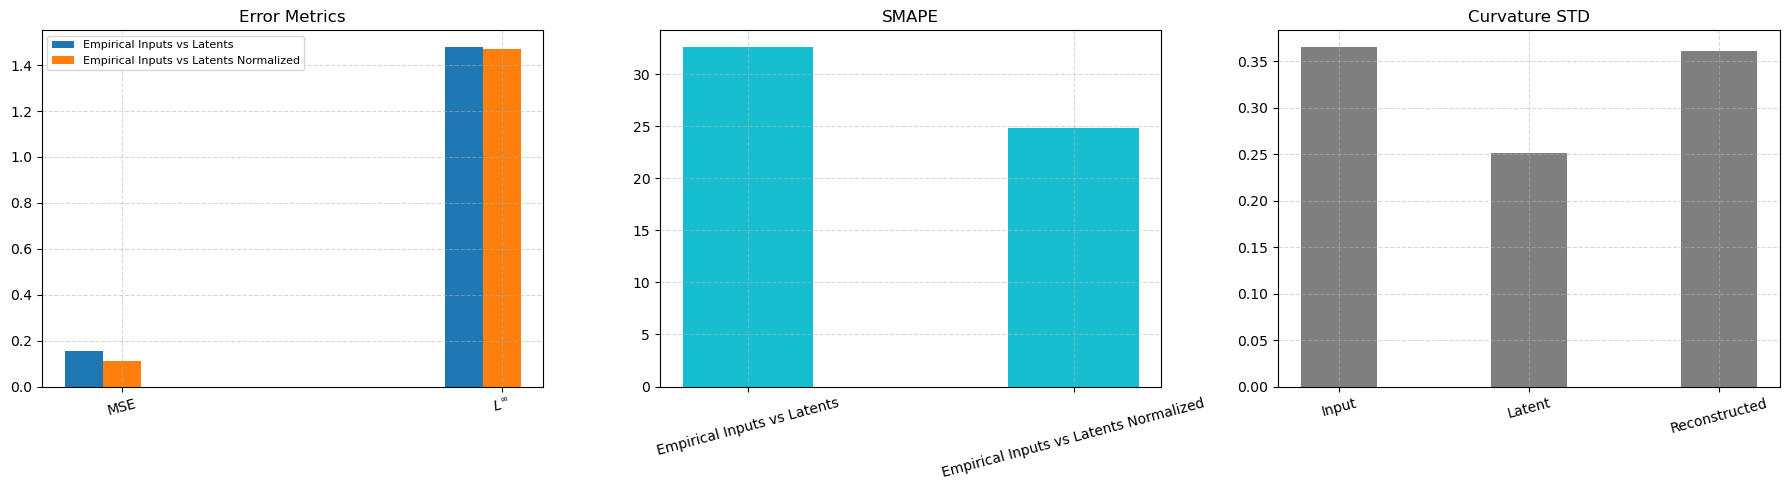

Execution time exp00_ae_sphere_w20_b64: 81.3367 seconds

Running exp01_ae_sphere_w20_b64. 
Description: alpha=1, gamma=0, dim_topo_loss=1
--------------------------------------------------------------------------------------


KeyboardInterrupt: 

In [186]:
run_experiment(all_configs=all_configs)